# Server RAM & CPU Usage Streamgraph Tracker

Streamgraphs are stylized stacked area charts centered around a horizontal baseline axis. They visualize flow fluctuations of multiple variables across time sequences without sharp angular bounds. This notebook simulates 24 hours of RAM usage (288 five-minute intervals) across five servers in a cluster, generating a streamgraph visualization using Matplotlib.



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Generate resource telemetry data (288 timestamps representing 24h in 5m intervals)
np.random.seed(140)
n_steps = 288
time_axis = np.linspace(0, 24, n_steps)

# Generate RAM usage streams per server node
# Base sinusoidal activity models daily workload peaks
base_activity = np.sin(time_axis * np.pi / 12 - np.pi/2) * 8 + 12

server_streams = []
for i in range(5):
    noise = np.random.normal(0, 1.5, n_steps)
    # Different offsets and frequencies per server node
    node_load = base_activity + (i * 3) + np.sin(time_axis * (i+1) * np.pi / 6) * 4 + noise
    server_streams.append(np.clip(node_load, 1.0, 64.0))

server_streams = np.array(server_streams)

df_sys = pd.DataFrame(server_streams.T, columns=[f"Server_{i+1}" for i in range(5)])
df_sys['Hour'] = time_axis
df_sys.head(10)



,Server_1,Server_2,Server_3,Server_4,Server_5,Hour
0,3.299248,6.803336,7.245010,14.797466,16.669882,0.000000
1,4.620995,6.378259,9.630817,14.151450,17.979939,0.083624
2,4.635722,8.100785,10.523151,15.392258,18.325252,0.167247
3,3.299014,8.282313,11.633913,15.856410,18.988079,0.250871
4,4.679752,8.745228,12.717606,16.362782,22.662797,0.334495
5,6.418938,10.273008,12.064698,16.943164,18.238904,0.418118
6,4.319535,9.913707,14.021022,17.289721,21.374378,0.501742
7,4.854838,9.038729,12.858975,15.739031,21.393889,0.585366
8,4.433876,10.137615,13.540663,14.511533,19.757751,0.668990
9,7.630657,8.969080,13.653740,16.820728,20.202560,0.752613


## Cluster Usage Aggregations

We calculate total cluster RAM consumption statistics across time intervals.



In [2]:
df_sys['Total_Cluster_RAM'] = df_sys[[f"Server_{i+1}" for i in range(5)]].sum(axis=1)
print("RAM Cluster Telemetry Stats (GB):")
df_sys['Total_Cluster_RAM'].describe()



RAM Cluster Telemetry Stats (GB):


count    288.000000
mean      90.327098
std       29.301668
min       30.206377
25%       65.349879
50%       90.817114
75%      116.485741
max      146.911448
Name: Total_Cluster_RAM, dtype: float64

## Matplotlib Symmetric Streamgraph Plot

We construct the streamgraph by calculating the cumulative sum baseline and shifting the stacked components symmetrically around zero.



<cell>:37: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



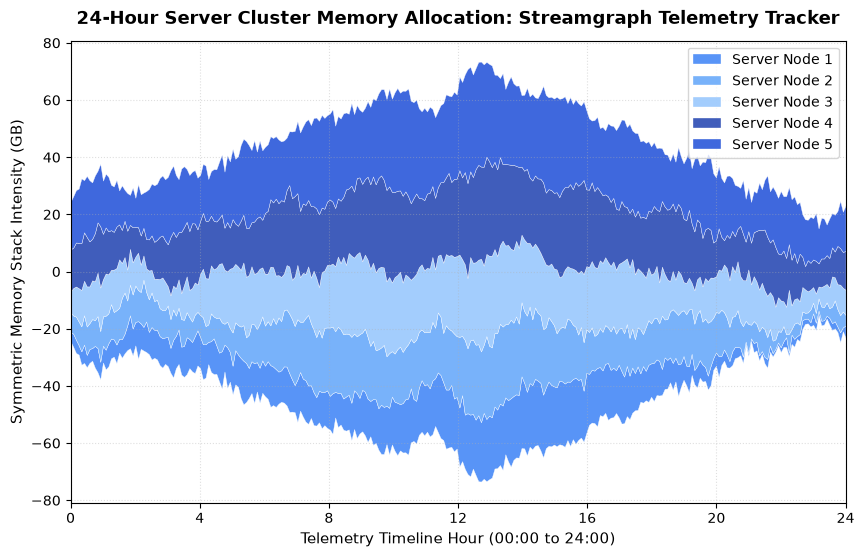

In [3]:
# Calculate cumulative sum stacks for baseline offsets
cum_sum = np.sum(server_streams, axis=0)
baseline = -cum_sum / 2.0 # Symmetrical offset baseline

# Offset each stream relative to baseline
streams_offset = []
current_baseline = baseline.copy()
for stream in server_streams:
    streams_offset.append(current_baseline.copy())
    current_baseline += stream

plt.figure(figsize=(10, 6))

colors = ['#3B82F6', '#60A5FA', '#93C5FD', '#1E40AF', '#1D4ED8']
labels = [f"Server Node {i+1}" for i in range(5)]

# Plot symmetric stream areas
for i in range(5):
    plt.fill_between(
        time_axis, 
        streams_offset[i], 
        streams_offset[i] + server_streams[i],
        color=colors[i],
        alpha=0.85,
        edgecolor='white',
        linewidth=0.3,
        label=labels[i]
    )

plt.title('24-Hour Server Cluster Memory Allocation: Streamgraph Telemetry Tracker', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Telemetry Timeline Hour (00:00 to 24:00)', fontsize=11)
plt.ylabel('Symmetric Memory Stack Intensity (GB)', fontsize=11)
plt.xlim(0, 24)
plt.xticks(np.arange(0, 25, 4))
plt.grid(True, linestyle=':', alpha=0.4)
plt.legend(loc='upper right')
plt.show()
